# The Sub 3-Hour Marathon

An achievement which many consider a prestigious milestone in endurance sport. Although even a sub-2-hour marathon is now possible, runners across the world, including myself, train and train for years on end to develop the aerobic fitness and speed to break through the 3 hour barrier. To discuss some insights on how to best achieve this, I turned to some data from the 2023 world marathon major, the Boston Marathon. This blog post, through regression modelling, will investigate the trends and factors that lead to specific marathon times, including gender patterns and the weather conditions on race day. My inspiration for this was so I could see what pacing strategy I will need to use to achieve the 3-hour threshold, but this analysis is applicable for all people. 

# Defining the Dataset

The data set used for this investigation is from the 2023 Boston Marathon, the most recent dataset of a marathon available via CSV file. This data was published by the Boston Athletic Association and I accessed this through the SCORE Sports Data Repository website, freely available online. What is contained in the CSV file is 26,598 rows of information, which is one for each individual finisher. This data contains 15 variables, with key metrics including age category, gender and half marathon split. Importantly, both gun and net time are given, although the net time is used for accuracy. 

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv('../data/boston_marathon_2023.csv')

# First look
print(df.shape)
print(df.head())
print(df.dtypes)

(26598, 15)
  age_group  place_overall  place_gender  place_division             name  \
0     18-39              1             1               1    Chebet, Evans   
1     18-39              2             2               2    Geay, Gabriel   
2     18-39              3             3               3  Kipruto, Benson   
3     18-39              4             4               4    Korir, Albert   
4     18-39              5             5               5   Talbi, Zouhair   

    team bib_number  half_time finish_net finish_gun gender  half_time_sec  \
0  Team–          1  1H 2M 20S  2H 5M 54S  2H 5M 54S      M         3740.0   
1  Team–          3  1H 2M 20S   2H 6M 4S   2H 6M 4S      M         3740.0   
2  Team–          5  1H 2M 19S   2H 6M 6S   2H 6M 6S      M         3739.0   
3  Team–         19  1H 2M 20S   2H 8M 1S   2H 8M 1S      M         3740.0   
4  Team–         31  1H 2M 20S  2H 8M 35S  2H 8M 35S      M         3740.0   

   finish_net_sec  finish_gun_sec  finish_net_minutes  


# Data Cleaning

Although the data contained 26,598 rows, 72 rows did not have either the half or full marathon finishing time, which is critical information for the study, so this left 26,526 clean records. The dataset already came in both seconds and minutes, although I also took the net seconds and divided them by 60 to ensure consistency. Finally, I created an additional variable which was a pace ratio measuring the second half split relative to the first, and an age midpoint variable to assist analysis as exact ages were not provided, rather only categories such as 18-39, 40-44, 45-49. 

In [2]:
# Data cleaning
# Drop any rows with missing finish times
df = df.dropna(subset=['finish_net_sec', 'half_time_sec'])

# Convert finish time to minutes for easier interpretation
df['finish_minutes'] = df['finish_net_sec'] / 60
df['half_minutes'] = df['half_time_sec'] / 60

# Create a pacing variable: ratio of second half to first half
# >1 means they slowed down (positive split), <1 means they sped up
df['pace_ratio'] = (df['finish_minutes'] - df['half_minutes']) / df['half_minutes']

print(f"Clean dataset: {df.shape[0]} runners")
print(f"\nAverage finish time: {df['finish_minutes'].mean():.1f} minutes ({df['finish_minutes'].mean()/60:.2f} hours)")
print(f"\nGender breakdown:")
print(df['gender'].value_counts())
print(f"\nAge group breakdown:")
print(df['age_group'].value_counts())

Clean dataset: 26526 runners

Average finish time: 222.5 minutes (3.71 hours)

Gender breakdown:
gender
M    15142
W    11384
Name: count, dtype: int64

Age group breakdown:
age_group
18-39    10139
40-44     4109
45-49     4058
50-54     3251
55-59     2233
60-64     1632
65-69      767
70-74      274
75-79       58
80+          5
Name: count, dtype: int64


# What Type of Runner Runs the Boston Marathon?

Out of the runners that completed the 2023 Boston Marathon, the average male finishing time was 3 hours and 32 minutes, while the average women’s finishing time was 3 hours and 56 minutes. As a reader, you may notice that the finish time distribution below has somewhat of a right skew to it. This is because a large amount of runners cluster in the middle, but many slower runners towards the back end extend the right, whereas a marathon can only be completed so quickly on the front end. The male distribution peak is around that 2 hour 55 to 3 hour time, and the women’s is roughly from 3 hours 40 to 3 hours 50. The mean for either gender can be seen through the dashed lines on the plot. 

# Why So Fast?

It is important to contextualise this race against other marathons. This marathon is largely seen as the most competitive as race entries are mostly determined through qualifying times. This differs from other marathon major events such as Sydney or London, which rely mostly on a ballot where there are even chances to be selected, no matter the pace. When analysing these results, if as the reader, you are not as advanced of a runner yet, these trends may be different from your marathon experience. That said, there are still some spots reserved by charities and corporate sponsors. This explains the diverse range of finishers, from as fast as a little over two hours, to as slow as over seven hours.

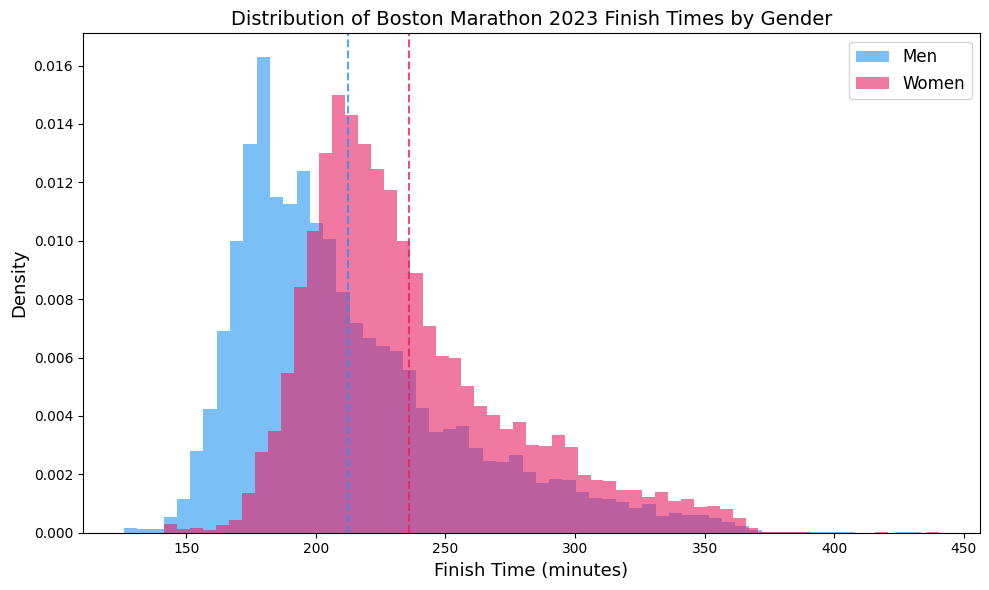

In [25]:
# Plot 1: Finish time distribution by gender
fig, ax = plt.subplots(figsize=(10, 6))

for gender, color, label in [('M', '#2196F3', 'Men'), ('W', '#E91E63', 'Women')]:
    subset = df[df['gender'] == gender]['finish_minutes']
    ax.hist(subset, bins=60, alpha=0.6, color=color, label=label, density=True)

ax.set_xlabel('Finish Time (minutes)', fontsize=13)
ax.set_ylabel('Density', fontsize=13)
ax.set_title('Distribution of Boston Marathon 2023 Finish Times by Gender', fontsize=14)
ax.legend(fontsize=12)
ax.axvline(df[df['gender']=='M']['finish_minutes'].mean(), color='#2196F3', linestyle='--', alpha=0.8)
ax.axvline(df[df['gender']=='W']['finish_minutes'].mean(), color='#E91E63', linestyle='--', alpha=0.8)

plt.tight_layout()
plt.savefig('../outputs/plot1_finish_distribution.png', dpi=150)
plt.show()

# Does Age Make a Difference?

As you may be able to assume, age certainly makes a difference. For both men and women, they progressively slow for total marathon time across each age group as they get older. For instance, males aged 18-39 are the fastest with an average of 3 hours 17 minutes. Whereas men aged 80+ average 4 hours and 58 minutes. (It is important to note this is an extraordinary accomplishment for anyone, let alone being this old) Women aged 18-39 averaged 3 hours and 48 minutes, with the 80+ women running an average of 5 hours 5 minutes. This is interesting, as the trend is that the gap between men and women narrows with age. The gap for 18–39-year-olds is 31 minutes, whereas for 75-79 and 80+ age groups, the gap is roughly 7-8 minutes. This scientifically makes sense, as both men and women age, although, to simplify a complex physiological concept, men’s testosterone levels also decrease with age which is linked largely to power output. 

To display this information, a bar chart has been used as age group represents a form of categorical data which uses distinct categories instead of a continuous scale. As mentioned, because the Boston marathon is more competitive than other major marathons, this may not necessarily be the exact trend seen at these other events. For instance, a roughly 5 hour marathon for an 80 year old is an extremely competitive time for that age category. 


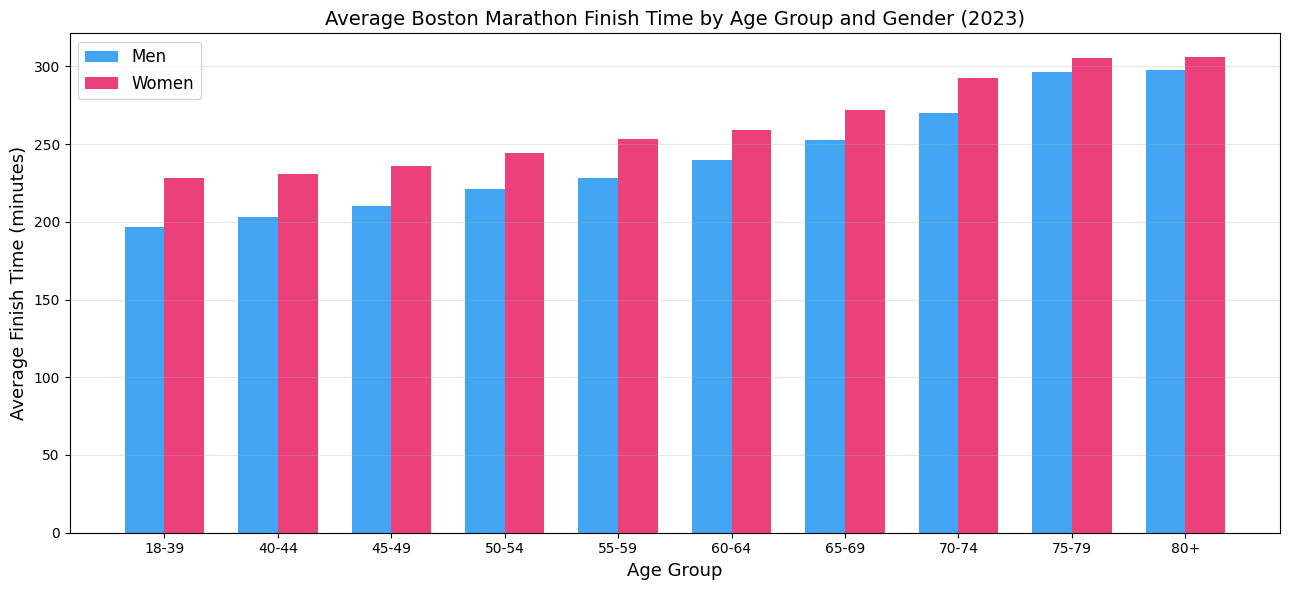

In [24]:
# Plot 2: Average finish time by age group and gender (bar chart - categorical data)
age_order = ['18-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80+']

avg_by_age = df.groupby(['age_group', 'gender'])['finish_minutes'].mean().reset_index()
avg_by_age['age_group'] = pd.Categorical(avg_by_age['age_group'], categories=age_order, ordered=True)
avg_by_age = avg_by_age.sort_values('age_group')

x = range(len(age_order))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))

men = avg_by_age[avg_by_age['gender'] == 'M']
women = avg_by_age[avg_by_age['gender'] == 'W']

bars1 = ax.bar([i - width/2 for i in x], men['finish_minutes'], width, 
               label='Men', color='#2196F3', alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], women['finish_minutes'], width, 
               label='Women', color='#E91E63', alpha=0.85)

ax.set_xlabel('Age Group', fontsize=13)
ax.set_ylabel('Average Finish Time (minutes)', fontsize=13)
ax.set_title('Average Boston Marathon Finish Time by Age Group and Gender (2023)', fontsize=14)
ax.set_xticks(list(x))
ax.set_xticklabels(age_order)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../outputs/plot2_age_gender.png', dpi=150)
plt.show()

# Hitting the Wall

In marathon running, there is a phenomenon known as hitting the wall, which happens about 30 kilometres into the run, where the body’s glycogen is depleted, and the body has no more energy expenditure from carbohydrates available. Most runners are fuelling their body during the run, but clearly not enough, as the trends suggest. When the glycogen runs out, the body burns fat instead and this is not as efficient as carbohydrates are for energy. This period where the pace drops is often the difference between achieving the goal time and missing out on it. 

# What Does Plot 3 Show Us?

In the Boston Marathon, rounded to the nearest percent, 100% of runners ran slower in the second half. It is very rare to negative split the Boston Marathon.  Along with hitting the wall, this does make sense, as the first half is net downhill, whereas the second half has the infamous Newton Hills and Heartbreak Hill, making the second half net uphill. These hills come right when the glycogen stores are depleted. Due to the runners largely still being at a competitive level, the average pace ratio was about 1.04, meaning that the second half takes about 4% longer than the first half. If this was a less competitive marathon, I would expect this number to be around 1.1 or larger. There were some outliers who finished by the second half much slower too. From the scraped information as well, because there was a 90% humidity on the day, this would exacerbate glycogen store depletion. Whilst it was about 9.5 degrees celcius, the humidity does not allow sweat to evaporate as fast, which makes the body work harder, and depletes glycogen faster, even with the cool temperature.

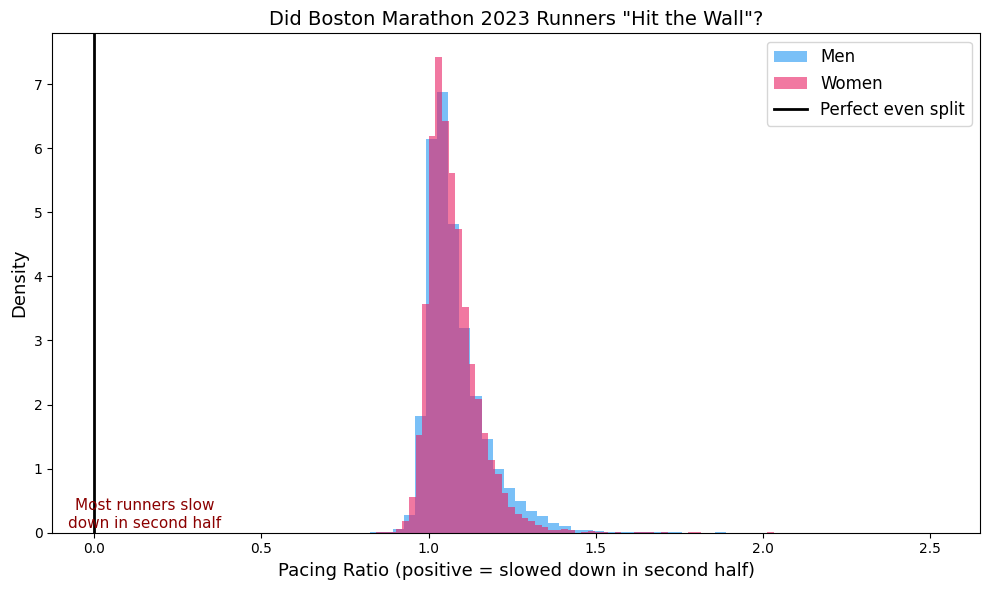

% of men who slowed down: 100.0%
% of women who slowed down: 100.0%


In [5]:
# Plot 3: Pacing analysis - do runners "hit the wall"?
fig, ax = plt.subplots(figsize=(10, 6))

for gender, color, label in [('M', '#2196F3', 'Men'), ('W', '#E91E63', 'Women')]:
    subset = df[df['gender'] == gender]['pace_ratio']
    ax.hist(subset, bins=60, alpha=0.6, color=color, label=label, density=True)

ax.axvline(0, color='black', linestyle='-', linewidth=2, label='Perfect even split')
ax.set_xlabel('Pacing Ratio (positive = slowed down in second half)', fontsize=13)
ax.set_ylabel('Density', fontsize=13)
ax.set_title('Did Boston Marathon 2023 Runners "Hit the Wall"?', fontsize=14)
ax.legend(fontsize=12)

# Add annotation
ax.annotate('Most runners slow\ndown in second half', xy=(0.15, 0.08), fontsize=11,
            color='darkred', ha='center')

plt.tight_layout()
plt.savefig('../outputs/plot3_pacing.png', dpi=150)
plt.show()

print(f"% of men who slowed down: {(df[df['gender']=='M']['pace_ratio'] > 0).mean()*100:.1f}%")
print(f"% of women who slowed down: {(df[df['gender']=='W']['pace_ratio'] > 0).mean()*100:.1f}%")

# What Does Plot 4 Show Us?

In order for the runners to run a perfectly even split they have to run both halves the same and would be dotted on the dashed line. There is a trend for the faster runners to sit on average closer to the line, seen in the bottom left, as they are more calculated and conservative with their pacing strategy. Whereas less experienced runners with a not as strong aerobic base will have their pace slow down exacerbated by the fact they are running for a longer period of time with no glycogen in their system. This is evidenced in the regression that highlights for every minute slower in the first half, it adds about 2.24 minutes to the total finish time, instead of just 2 minutes. What this means is if you go out too hard, the time you lose is disproportionately more than the time you gain from going faster at the start.

# The Key Takeaway for the Wall

Strategy and patience are underrated when it comes to the marathon. To run a sub 3-hour marathon, which is a goal of mine like many others, the strategy will be to go out at that pace, or maybe even slightly slower, instead of banking time and then blowing up in the back half of the race. That said, running fast up the hills in the second half will be a challenge too.

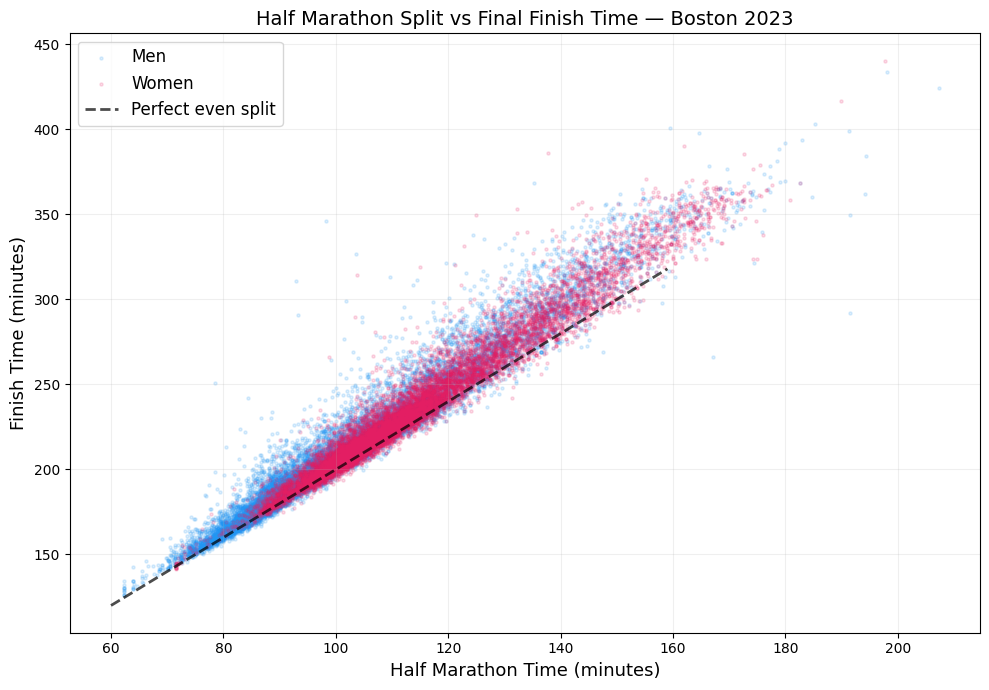

In [29]:
# Plot 4: Half time vs finish time scatter plot
fig, ax = plt.subplots(figsize=(10, 7))

for gender, color, label in [('M', '#2196F3', 'Men'), ('W', '#E91E63', 'Women')]:
    subset = df[df['gender'] == gender]
    ax.scatter(subset['half_minutes'], subset['finish_minutes'], 
               alpha=0.15, color=color, label=label, s=5)

# Add perfect pace line (if you ran same pace both halves)
x = range(60, 160)
ax.plot(x, [i*2 for i in x], 'k--', linewidth=2, label='Perfect even split', alpha=0.7)

ax.set_xlabel('Half Marathon Time (minutes)', fontsize=13)
ax.set_ylabel('Finish Time (minutes)', fontsize=13)
ax.set_title('Half Marathon Split vs Final Finish Time — Boston 2023', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../outputs/plot4_half_vs_finish.png', dpi=150)
plt.show()

# Regression Model

For the analysis, I used Ordinary Least Squares regression, which you may have used in high school to find the line of best fit. It calculates the relationship between certain variables. Here, I have attempted to predict a dependent variable, being finish time, based on other independent variables available which include age, gender, and importantly, half-way split time. It is important to note, that the half-way split time was used in minutes, the age midpoint was used for each age category, and for the gender coding, men were 1 and women were 0. 

# Results

The R^2 measurement came out to 0.955, which means that this regression model for finish time prediction explains over 95% of variation for finishing times. This makes clear sense as most people will go into the race planning on holding the same pace, but marathons are infamous for falling off in the second half. The remaining percent not accounted for in this regression model will likely be down to factors like nutrition, training, attitude to the event and potentially how they handle those hills. 

# Half-Marathon Coefficient: 2.24

As mentioned earlier, this coefficient calculates that for each minute additionally ran in the first half of the race, it on average increases the final time by 2.24 minutes, as opposed to 2 minutes roughly. This coefficient is definitely the strongest predictor of finishing time, and also proves the point that if you go out too hot, it will more than likely cost you in the second half. From personal experience, not having the energy you need in the second half of a race and slowing down can be demoralising too, so bear this in mind. 

# Age Midpoint Coefficient: -0.015

As the CSV file used only provides the age category and not the actual age themselves, these results would vary if there was access to the ages. However, this data is still useful. What it means is for every year older a runner is, their predicted finish time decreases by 0.015 minutes, which approximately equates to one second. The reason for this is because even though older runners are slower based on the raw data, this regression model controls the coefficient for half marathon time and gender. Essentially, if you take two runners who run the same first half time of the race, and are of the same gender, the older runner would be predicted to finish faster. I would likely put this down to experience. Older runners have likely run more marathons before which means they know what their body is capable of and how demanding the second half of a marathon can be. Nevertheless, the coefficient is quite small, that in the grand scheme, it will not make a substantial difference in comparison to half marathon time split. 

# Male Gender coefficient: 3.06

Due to the code using men as 1 and women as 0, this means that accounting for half marathon splits, men on average add 3.06 minutes to their predicted time. Similarly to above, even though on average men finish the race faster, accounting for half marathon time means if you took a man and woman who went through the half marathon point in the same amount of time, the woman would tend to finish roughly three minutes faster. From my own personal experience, this makes sense as men often ambitiously go out too hard in races, whereas women are more likely to be calculated and sensible with pacing strategies, leading to a better race execution.

In [7]:
# Plot 5 + Unit 5: OLS Regression - predicting finish time
# Create a numeric age variable from age groups
age_map = {'18-39': 28, '40-44': 42, '45-49': 47, '50-54': 52, 
           '55-59': 57, '60-64': 62, '65-69': 67, '70-74': 72, '75-79': 77, '80+': 82}
df['age_mid'] = df['age_group'].map(age_map)
df['is_male'] = (df['gender'] == 'M').astype(int)

# Run OLS regression
model = smf.ols('finish_minutes ~ half_minutes + age_mid + is_male', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         finish_minutes   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                 1.856e+05
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:57:26   Log-Likelihood:                -96866.
No. Observations:               26526   AIC:                         1.937e+05
Df Residuals:                   26522   BIC:                         1.938e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      -18.5095      0.371    -49.931   

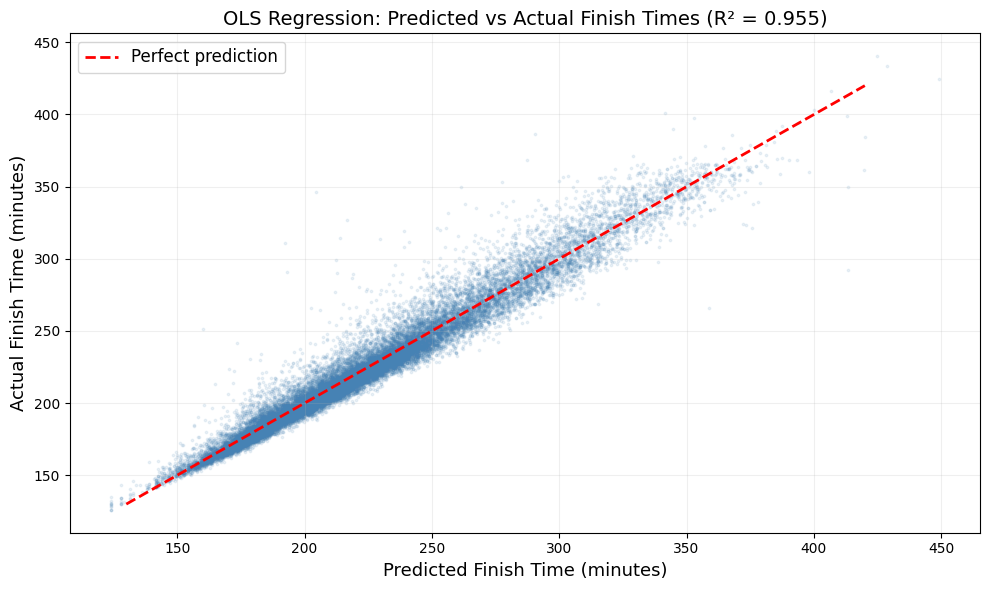

In [26]:
# Plot 5: Regression coefficients visualised
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter actual vs predicted
df['predicted'] = model.predict(df)
ax.scatter(df['predicted'], df['finish_minutes'], alpha=0.1, s=3, color='steelblue')
ax.plot([130, 420], [130, 420], 'r--', linewidth=2, label='Perfect prediction')

ax.set_xlabel('Predicted Finish Time (minutes)', fontsize=13)
ax.set_ylabel('Actual Finish Time (minutes)', fontsize=13)
ax.set_title(f'OLS Regression: Predicted vs Actual Finish Times (R² = 0.955)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../outputs/plot5_regression.png', dpi=150)
plt.show()

       Count  Avg Finish (mins)  Fastest (mins)  Slowest (mins)  Avg Half (mins)
Men    15142              212.4           125.9           433.6            101.8
Women  11384              236.0           141.6           440.5            113.6


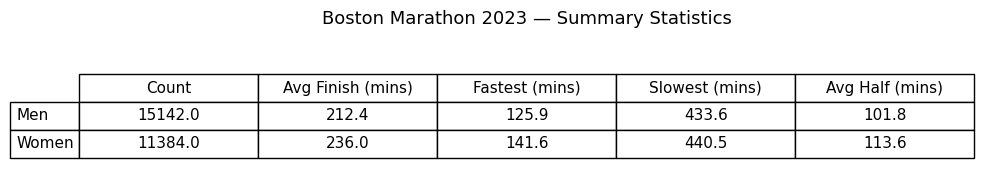

In [21]:
# Plot 6: Summary statistics table
summary = df.groupby('gender').agg(
    Count=('finish_minutes', 'count'),
    Avg_Finish=('finish_minutes', 'mean'),
    Fastest=('finish_minutes', 'min'),
    Slowest=('finish_minutes', 'max'),
    Avg_Half=('half_minutes', 'mean')
).round(1)

summary.index = ['Men', 'Women']
summary.columns = ['Count', 'Avg Finish (mins)', 'Fastest (mins)', 'Slowest (mins)', 'Avg Half (mins)']

print(summary.to_string())

fig, ax = plt.subplots(figsize=(10, 2))
ax.axis('off')
table = ax.table(cellText=summary.values, colLabels=summary.columns, 
                 rowLabels=summary.index, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)

plt.title('Boston Marathon 2023 — Summary Statistics', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig('../outputs/plot6_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 5 and 6 + Takeaways

Plot 5 demonstrates predicted times as opposed to the actual finish time. If the model was a perfect representation, all the finishing times would be on the Plot 5 red line. Although, the dots being clustered in and around the line do represent the R^2 of 0.955 being accurate. It is slightly less clustered around the slower finishing times, so this may be more accurate for faster finishers. This also aligns with the general overview provided in the Plot 6 Summary Statistics. This model therefore, because it only uses three variables of the many available such as training, nutrition and heart rate, and only uses one year’s data from one course and course conditions, likely means the results would change if tried elsewhere. As well, this is merely a correlation, and does not represent these variables causing certain times.

In [20]:
# Analysis for 21-year-old male targeting 3 hours
# Look at runners who finished between 175-185 minutes (around 3 hours)
three_hour_runners = df[(df['finish_minutes'] >= 175) & 
                        (df['finish_minutes'] <= 185) & 
                        (df['gender'] == 'M')]

print(f"Runners who finished around 3 hours (175-185 mins): {len(three_hour_runners)}")
print(f"\nTheir average half marathon time: {three_hour_runners['half_minutes'].mean():.1f} mins")
print(f"Their fastest half: {three_hour_runners['half_minutes'].min():.1f} mins")
print(f"Their slowest half: {three_hour_runners['half_minutes'].max():.1f} mins")
print(f"\nAverage pace ratio (slowing factor): {three_hour_runners['pace_ratio'].mean():.3f}")
print(f"\nSo to run 3 hours, you realistically need a half split of:")
print(f"  Conservative: {three_hour_runners['half_minutes'].quantile(0.25):.1f} mins")
print(f"  Average:      {three_hour_runners['half_minutes'].mean():.1f} mins")
print(f"  Aggressive:   {three_hour_runners['half_minutes'].quantile(0.75):.1f} mins")

Runners who finished around 3 hours (175-185 mins): 2243

Their average half marathon time: 88.0 mins
Their fastest half: 76.8 mins
Their slowest half: 94.9 mins

Average pace ratio (slowing factor): 1.042

So to run 3 hours, you realistically need a half split of:
  Conservative: 86.8 mins
  Average:      88.0 mins
  Aggressive:   89.4 mins


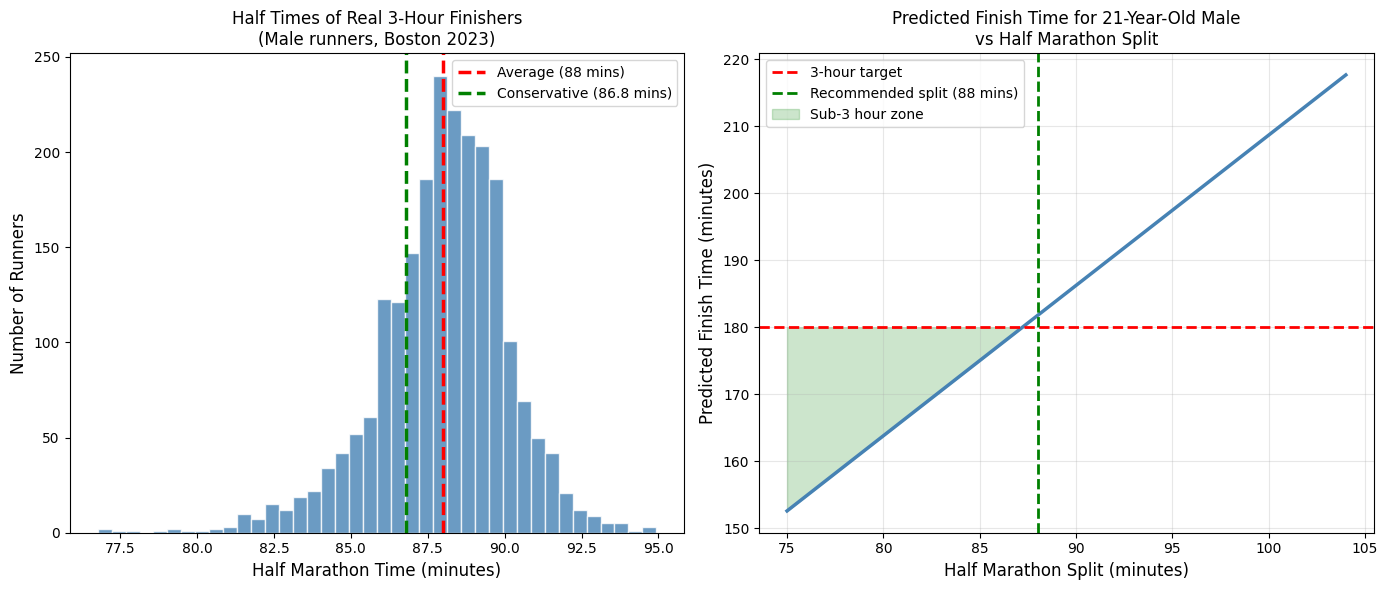

In [27]:
# Plot 7: Personal 3-hour target analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: distribution of half times for 3-hour finishers
axes[0].hist(three_hour_runners['half_minutes'], bins=40, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(88.0, color='red', linestyle='--', linewidth=2.5, label='Average (88 mins)')
axes[0].axvline(86.8, color='green', linestyle='--', linewidth=2.5, label='Conservative (86.8 mins)')
axes[0].set_xlabel('Half Marathon Time (minutes)', fontsize=12)
axes[0].set_ylabel('Number of Runners', fontsize=12)
axes[0].set_title('Half Times of Real 3-Hour Finishers\n(Male runners, Boston 2023)', fontsize=12)
axes[0].legend(fontsize=10)

# Right: finish time predictor for a 21-year-old male
half_times = range(75, 105)
predicted_finish = [2.2446*h - 18.5095 + 3.0583 - 0.0149*21 for h in half_times]

axes[1].plot(half_times, predicted_finish, color='steelblue', linewidth=2.5)
axes[1].axhline(180, color='red', linestyle='--', linewidth=2, label='3-hour target')
axes[1].axvline(88, color='green', linestyle='--', linewidth=2, label='Recommended split (88 mins)')
axes[1].fill_between(half_times, predicted_finish, 180, 
                      where=[p <= 180 for p in predicted_finish],
                      alpha=0.2, color='green', label='Sub-3 hour zone')
axes[1].set_xlabel('Half Marathon Split (minutes)', fontsize=12)
axes[1].set_ylabel('Predicted Finish Time (minutes)', fontsize=12)
axes[1].set_title('Predicted Finish Time for 21-Year-Old Male\nvs Half Marathon Split', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plot7_personal_target.png', dpi=150)
plt.show()

# Web Scraping

To give context for the environment the race was run in, which helped in the above analysis, I scraped the weather from the day of the marathon. Web scraping is the automated extraction of data from a website instead of a manual copying of the information. The scraped data was sourced from the Open-Meteo Historical Weather API which had hour-by-hour conditions for 7am until 1pm on the 17th of April 2023. This data includes temperature, humidity, rain and wind speed. It is noted there was no rain on the day.

In [12]:
# Web Scraping: Boston weather on race day (April 17, 2023)
import requests
from bs4 import BeautifulSoup

url = "https://www.wunderground.com/history/daily/us/ma/boston/KBOS/date/2023-4-17"

headers = {
    'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

response = requests.get(url, headers=headers)
print(f"Status code: {response.status_code}")
print(f"Page retrieved: {len(response.text)} characters")

Status code: 200
Page retrieved: 247804 characters


In [13]:
# Parse the weather data
soup = BeautifulSoup(response.text, 'html.parser')

# Find temperature and weather observations
tables = soup.find_all('table')
print(f"Found {len(tables)} tables on page")

# Try to extract key weather facts
# Look for summary data
divs = soup.find_all('div', class_=lambda x: x and 'summary' in x.lower())
print(f"Found {len(divs)} summary divs")

# Print a snippet of the page to see what data is available
spans = soup.find_all('span')
for span in spans[:50]:
    if span.text.strip() and len(span.text.strip()) < 50:
        print(span.text.strip())

Found 0 tables on page
Found 2 summary divs
Sensor Network
Maps & Radar
Severe Weather
News & Blogs
Mobile Apps
More
close
gps_fixed
Log in
Settings
Sensor Network
Maps & Radar
Severe Weather


In [14]:
# Web Scraping: Use Open-Meteo API for Boston race day weather (April 17, 2023)
import requests
import json

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 42.3601,
    "longitude": -71.0589,
    "start_date": "2023-04-17",
    "end_date": "2023-04-17",
    "hourly": "temperature_2m,relativehumidity_2m,windspeed_10m,precipitation",
    "timezone": "America/New_York",
    "temperature_unit": "celsius"
}

response = requests.get(url, params=params)
data = response.json()

print(f"Status code: {response.status_code}")
print(json.dumps(data, indent=2))

Status code: 200
{
  "latitude": 42.355007,
  "longitude": -71.12906,
  "generationtime_ms": 5.680680274963379,
  "utc_offset_seconds": -14400,
  "timezone": "America/New_York",
  "timezone_abbreviation": "GMT-4",
  "elevation": 9.0,
  "hourly_units": {
    "time": "iso8601",
    "temperature_2m": "\u00b0C",
    "relativehumidity_2m": "%",
    "windspeed_10m": "km/h",
    "precipitation": "mm"
  },
  "hourly": {
    "time": [
      "2023-04-17T00:00",
      "2023-04-17T01:00",
      "2023-04-17T02:00",
      "2023-04-17T03:00",
      "2023-04-17T04:00",
      "2023-04-17T05:00",
      "2023-04-17T06:00",
      "2023-04-17T07:00",
      "2023-04-17T08:00",
      "2023-04-17T09:00",
      "2023-04-17T10:00",
      "2023-04-17T11:00",
      "2023-04-17T12:00",
      "2023-04-17T13:00",
      "2023-04-17T14:00",
      "2023-04-17T15:00",
      "2023-04-17T16:00",
      "2023-04-17T17:00",
      "2023-04-17T18:00",
      "2023-04-17T19:00",
      "2023-04-17T20:00",
      "2023-04-17T21:00"

In [15]:
# Process the weather data for race hours (7am - 2pm, when most runners are racing)
hours = data['hourly']['time']
temps = data['hourly']['temperature_2m']
humidity = data['hourly']['relativehumidity_2m']
windspeed = data['hourly']['windspeed_10m']
precipitation = data['hourly']['precipitation']

# Create a dataframe
weather_df = pd.DataFrame({
    'time': hours,
    'temperature_c': temps,
    'humidity': humidity,
    'windspeed_kmh': windspeed,
    'precipitation_mm': precipitation
})

# Filter for race hours (7am to 2pm)
race_hours = weather_df[weather_df['time'].between('2023-04-17T07', '2023-04-17T14')]

print("Boston Weather on Race Day (April 17, 2023)")
print("=" * 50)
print(f"Average temperature: {race_hours['temperature_c'].mean():.1f}°C ({race_hours['temperature_c'].mean() * 9/5 + 32:.1f}°F)")
print(f"Average humidity:    {race_hours['humidity'].mean():.1f}%")
print(f"Average wind speed:  {race_hours['windspeed_kmh'].mean():.1f} km/h")
print(f"Total precipitation: {race_hours['precipitation_mm'].sum():.1f} mm")
print(f"\nPeak temperature:    {race_hours['temperature_c'].max():.1f}°C")
print(f"Min temperature:     {race_hours['temperature_c'].min():.1f}°C")

Boston Weather on Race Day (April 17, 2023)
Average temperature: 9.8°C (49.6°F)
Average humidity:    90.6%
Average wind speed:  13.2 km/h
Total precipitation: 0.0 mm

Peak temperature:    11.8°C
Min temperature:     8.7°C


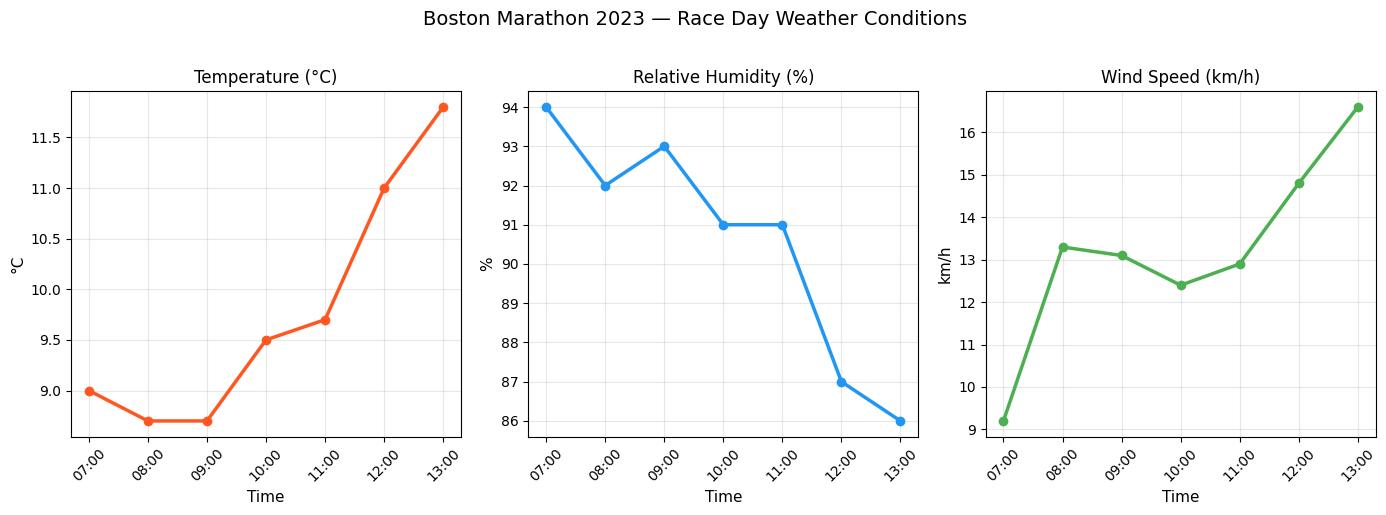

In [28]:
# Plot 8: Race day weather conditions
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

time_labels = [t.split('T')[1][:5] for t in race_hours['time'].values]

# Temperature
axes[0].plot(range(len(race_hours)), race_hours['temperature_c'], 
             color='#FF5722', linewidth=2.5, marker='o')
axes[0].set_title('Temperature (°C)', fontsize=12)
axes[0].set_xlabel('Time', fontsize=11)
axes[0].set_ylabel('°C', fontsize=11)
axes[0].set_xticks(range(len(race_hours)))
axes[0].set_xticklabels(time_labels, rotation=45)
axes[0].grid(True, alpha=0.3)

# Humidity
axes[1].plot(range(len(race_hours)), race_hours['humidity'],
             color='#2196F3', linewidth=2.5, marker='o')
axes[1].set_title('Relative Humidity (%)', fontsize=12)
axes[1].set_xlabel('Time', fontsize=11)
axes[1].set_ylabel('%', fontsize=11)
axes[1].set_xticks(range(len(race_hours)))
axes[1].set_xticklabels(time_labels, rotation=45)
axes[1].grid(True, alpha=0.3)

# Wind speed
axes[2].plot(range(len(race_hours)), race_hours['windspeed_kmh'],
             color='#4CAF50', linewidth=2.5, marker='o')
axes[2].set_title('Wind Speed (km/h)', fontsize=12)
axes[2].set_xlabel('Time', fontsize=11)
axes[2].set_ylabel('km/h', fontsize=11)
axes[2].set_xticks(range(len(race_hours)))
axes[2].set_xticklabels(time_labels, rotation=45)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Boston Marathon 2023 — Race Day Weather Conditions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/plot8_weather.png', dpi=150, bbox_inches='tight')
plt.show()

# Using Myself as an Example

To prove how this information can be somewhat useful, I will use what I have gathered and apply it to my own goal of running a sub 3 hour marathon. If I put my details of being a 21 year old male into the regression equation, it would suggest that in order for me to go sub 3 hours, instead of going through the half marathon mark in an even split of 90 minutes, it suggests 88 minutes. This aligns with the raw data where the closest 2,243 around the 3 hour final time, on average went through the half in 88 minutes.

This makes my decision difficult, as I am not elite, so I do not have the pacing strategy down perfect, so the research would suggest I need to split the half marathon in 88 minutes in order to account for the slowdown that as a 21-year-old male inexperienced in this distance, is likely inevitable. However, there is a fine line, as if I went out in the first half in 84 minutes, that might be too much for my body to cope with in the second half, adding a disproportionate amount of time instead of banking time.  This analysis has given me a lot more to think about, strategy wise.


# Conclusions and How to Improve the Analysis

There are a few improvements I would make to increase the accuracy of this model, including testing it over different courses, multiple years, allowing for different climates. I would also like to find a way to analyse DNF results, as some people will hit the wall so intensely they will remove themselves from the race. Conversely, this analysis provides great insight into the strategy when it comes to the marathon and how the first half can make or break the race. 